# SVM L1 & SVM L2 Classification
## Based on ML Notebook 3B: Linear Models for Classification
Organized following the structure of Christopher Monterola, Kenneth Co., and Gino Borja.

**Sections:**
- **Part A — SVM L1:** Single C → Range of C → Monte Carlo Tuning → Best C & Best Feature
- **Part B — SVM L2:** Single C → Range of C → Monte Carlo Tuning → Best C & Best Feature


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

pd.options.display.float_format = '{:,.4g}'.format


## 1. Load Data
Change `CSV_PATH` to match your groupmates' CSV file.

In [2]:
CSV_PATH   = "/Users/licahc/Downloads/amazon_bestsellers_reviews_cleaned_clustered.csv"    
TARGET_COL = "is helpful"                       

df_raw = pd.read_csv(CSV_PATH)

print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(df_raw.dtypes)
df_raw.head()


Loaded: 1,519 rows x 30 columns
department              object
product_index            int64
product_name            object
product_url             object
reviewer                object
rating                   int64
date                    object
verified                object
title                   object
body                    object
helpful_votes            int64
variant                 object
image_count              int64
location                object
is_helpful               int64
text_for_lsa            object
year                     int64
month                    int64
day_of_week              int64
review_age_days          int64
location_freq            int64
title_len                int64
body_len                 int64
word_count               int64
avg_word_len           float64
sentiment              float64
sentiment_extremity    float64
cluster_kmeans           int64
cluster_dbscan           int64
cluster_hac              int64
dtype: object


,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,...,location_freq,title_len,body_len,word_count,avg_word_len,sentiment,sentiment_extremity,cluster_kmeans,cluster_dbscan,cluster_hac
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,...,1190,31,557,61,9.131,0.9876,0.9876,0,0,4
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",...,1190,23,495,43,11.51,0.9547,0.9547,2,0,4
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,...,1190,56,1369,135,10.14,0.9857,0.9857,0,0,4
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,...,1190,31,935,82,11.4,0.9953,0.9953,0,0,4
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",...,1190,51,132,20,6.6,0.9705,0.9705,0,0,4


## 2. Preprocessing
Mirrors the `data_cleaner` notebook pipeline.

In [3]:
import re, string
df = df_raw.copy()

# Parse date column into location + date
if 'date' in df.columns and df['date'].dtype == object:
    pattern = r'Reviewed in (.+?) on (.+)'
    extracted = df['date'].str.extract(pattern)
    if extracted.notna().all(axis=None):
        df[['location', 'date']] = extracted
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# helpful_votes -> numeric -> binary target
if 'helpful_votes' in df.columns and df['helpful_votes'].dtype == object:
    df['helpful_votes'] = df['helpful_votes'].str.extract(r'(One|\d+)')[0]
    df['helpful_votes'] = df['helpful_votes'].replace('One', '1')
    df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0).astype(int)

if TARGET_COL not in df.columns:
    if 'helpful_votes' in df.columns:
        df[TARGET_COL] = (df['helpful_votes'] > 0).astype(int)
    else:
        raise ValueError(f"Cannot find or derive target column '{TARGET_COL}'")

# Rating
if 'rating' in df.columns:
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(df['rating'].median()).astype(int)

# Date-derived features
if 'date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['date']):
    df['year']        = df['date'].dt.year.astype('Int64')
    df['month']       = df['date'].dt.month.astype('Int64')
    df['day_of_week'] = df['date'].dt.dayofweek.astype('Int64')

# Location frequency-encode
if 'location' in df.columns:
    loc_freq = df['location'].value_counts()
    df['location_freq'] = df['location'].map(loc_freq).fillna(0).astype(int)

# Verified purchase
if 'verified_purchase' in df.columns:
    df['verified_purchase'] = df['verified_purchase'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0})
    df['verified_purchase'] = pd.to_numeric(df['verified_purchase'], errors='coerce').fillna(0).astype(int)

# Text length features
for col in ['title', 'body']:
    if col in df.columns:
        df[col] = df[col].fillna('')
        df[f'{col}_len'] = df[col].str.len().astype(int)

if 'body' in df.columns and 'title' in df.columns:
    df['text_combined'] = (df['title'] + ' ' + df['body']).str.lower()
    df['word_count'] = df['text_combined'].str.split().str.len().fillna(0).astype(int)

print(f"DataFrame after preprocessing: {df.shape}")
df.head()


DataFrame after preprocessing: (1519, 32)


,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,...,body_len,word_count,avg_word_len,sentiment,sentiment_extremity,cluster_kmeans,cluster_dbscan,cluster_hac,is helpful,text_combined
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,...,557,93,9.131,0.9876,0.9876,0,0,4,1,best-in-class quality and sound these apple ea...
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",...,495,86,11.51,0.9547,0.9547,2,0,4,1,great sound and comfort i bought these for my ...
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,...,1369,227,10.14,0.9857,0.9857,0,0,4,1,"the $9 audiophile secret: small dongle, big pr..."
3,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,K,5,2026-03-17,Verified Purchase,better than overhead headphones,I honestly love these headphones so much. I ac...,...,935,164,11.4,0.9953,0.9953,0,0,4,1,better than overhead headphones i honestly lov...
4,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Low,5,2026-04-25,Verified Purchase,Worth the extra money. They're the best ones I...,"Best you can buy. I have 4 usbc ear buds, thes...",...,132,36,6.6,0.9705,0.9705,0,0,4,0,worth the extra money. they're the best ones i...


## 3. Feature Selection

In [4]:
EXCLUDE = {TARGET_COL, 'is_helpful', 'helpful_votes', 'date', 'title', 'body',
           'text_combined', 'text_for_lsa', 'location',
           'cluster_kmeans', 'cluster_dbscan', 'asin', 'reviewer_id'}

feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE
    and pd.api.types.is_numeric_dtype(df[c])
    and df[c].notna().sum() > 0
]

print("Feature columns selected:")
for c in feature_cols:
    print(f"  {c}")

X_all = df[feature_cols].fillna(0).values
y_all = df[TARGET_COL].values

# Auto-detect unique class labels (works for any CSV)
unique_classes = np.unique(y_all)
target_names   = [str(c) for c in unique_classes]

print(f"\nX shape : {X_all.shape}")
print(f"y shape : {y_all.shape}")
print(f"Classes : {unique_classes}  ->  {target_names}")
print(f"Class balance: {np.bincount(y_all.astype(int)) if y_all.dtype != object else 'see value_counts'}")


Feature columns selected:
  product_index
  rating
  image_count
  year
  month
  day_of_week
  review_age_days
  location_freq
  title_len
  body_len
  word_count
  avg_word_len
  sentiment
  sentiment_extremity
  cluster_hac

X shape : (1519, 15)
y shape : (1519,)
Classes : [0 1]  ->  ['0', '1']
Class balance: [595 924]


## 4. Train / Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train_sc.shape[0]:,}  |  Test size: {X_test_sc.shape[0]:,}")


Train size: 1,139  |  Test size: 380


---
# Part A — Support Vector Machine with L1 Regularization (SVM L1)

`LinearSVC(penalty="l1", loss='squared_hinge', dual=False)`

**Higher C = less regularization** (same interpretation as ML Notebook 3B Section D).


### A-1. SVM L1 — Single C (C = 1)

In [6]:
# SVM L1 with C = 1
C_single_l1 = 1

svm_l1_single = LinearSVC(
    C=C_single_l1,
    penalty="l1",
    loss='squared_hinge',
    dual=False,
    max_iter=10000
).fit(X_train_sc, y_train)

print(f"SVM L1  |  C = {C_single_l1}")
print(f"  Training set score : {svm_l1_single.score(X_train_sc, y_train):.6f}")
print(f"  Test set score     : {svm_l1_single.score(X_test_sc,  y_test):.6f}")


SVM L1  |  C = 1
  Training set score : 0.825285
  Test set score     : 0.828947


In [7]:
# Classification Report — SVM L1, C = 1
y_pred_l1_single = svm_l1_single.predict(X_test_sc)
print("Classification Report (SVM L1, C=1):")
print(classification_report(y_test, y_pred_l1_single,
                             labels=unique_classes, target_names=target_names))


Classification Report (SVM L1, C=1):
              precision    recall  f1-score   support

           0       0.91      0.61      0.73       145
           1       0.80      0.96      0.87       235

    accuracy                           0.83       380
   macro avg       0.85      0.79      0.80       380
weighted avg       0.84      0.83      0.82       380



/var/folders/pm/m1_pb85j4pg9khxpn240nmth0000gn/T/ipykernel_11447/3406642287.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=30, ha='left')
/var/folders/pm/m1_pb85j4pg9khxpn240nmth0000gn/T/ipykernel_11447/3406642287.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(tick_labels)


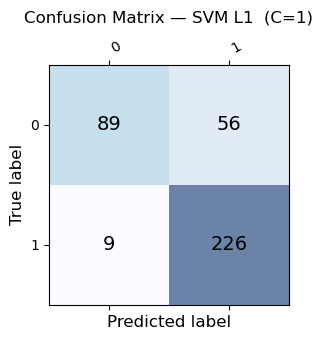

In [8]:
# Confusion Matrix — SVM L1, C = 1
confmat_l1_single = confusion_matrix(y_true=y_test, y_pred=y_pred_l1_single,
                                     labels=unique_classes)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.matshow(confmat_l1_single, cmap=plt.cm.Blues, alpha=0.6)
for i in range(confmat_l1_single.shape[0]):
    for j in range(confmat_l1_single.shape[1]):
        ax.text(x=j, y=i, s=confmat_l1_single[i, j], va='center', ha='center', fontsize=14)
tick_labels = [''] + target_names
ax.set_xticklabels(tick_labels, rotation=30, ha='left')
ax.set_yticklabels(tick_labels)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(f'Confusion Matrix — SVM L1  (C={C_single_l1})', fontsize=12, pad=12)
plt.tight_layout()
plt.show()


### A-2. SVM L1 — Range of C Values

In [9]:
# SVM L1: scores over a range of C values (single split)
C_range_l1 = [1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

train_scores_l1 = []
test_scores_l1  = []

for c in C_range_l1:
    svm = LinearSVC(C=c, penalty="l1", loss='squared_hinge', dual=False, max_iter=10000)
    svm.fit(X_train_sc, y_train)
    train_scores_l1.append(svm.score(X_train_sc, y_train))
    test_scores_l1.append(svm.score(X_test_sc,  y_test))
    print(f"C = {c:>8}  |  train: {train_scores_l1[-1]:.4f}  |  test: {test_scores_l1[-1]:.4f}")


C =   0.0001  |  train: 0.3951  |  test: 0.3816
C =    0.001  |  train: 0.8227  |  test: 0.8316
C =      0.1  |  train: 0.8244  |  test: 0.8342
C =      0.2  |  train: 0.8235  |  test: 0.8342
C =      0.4  |  train: 0.8244  |  test: 0.8342
C =     0.75  |  train: 0.8235  |  test: 0.8342
C =        1  |  train: 0.8262  |  test: 0.8289
C =      1.5  |  train: 0.8253  |  test: 0.8289
C =        3  |  train: 0.8367  |  test: 0.8395
C =        5  |  train: 0.8349  |  test: 0.8474
C =       10  |  train: 0.8358  |  test: 0.8500
C =       15  |  train: 0.8376  |  test: 0.8526
C =       20  |  train: 0.8385  |  test: 0.8526
C =      100  |  train: 0.8358  |  test: 0.8526
C =      300  |  train: 0.8358  |  test: 0.8526
C =     1000  |  train: 0.8358  |  test: 0.8526
C =     5000  |  train: 0.8358  |  test: 0.8526


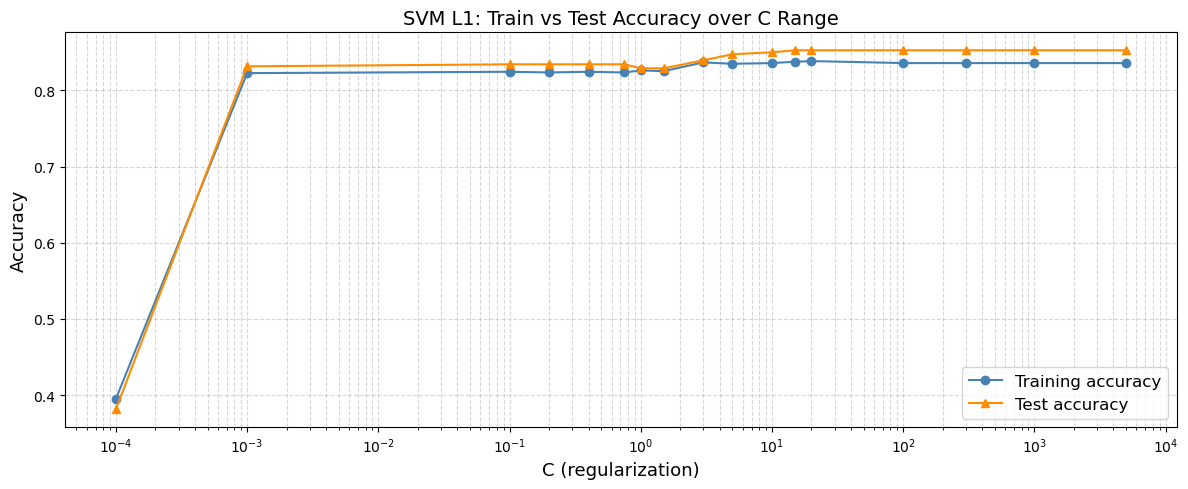

Best test accuracy (single split): 0.852632
Best C (single split)            : 15


In [10]:
# Plot — SVM L1 range of C
fig = plt.figure(figsize=(12, 5))
plt.xscale('log')
plt.plot(C_range_l1, train_scores_l1, '-o', label='Training accuracy', color='steelblue')
plt.plot(C_range_l1, test_scores_l1,  '-^', label='Test accuracy',     color='darkorange')
plt.xlabel('C (regularization)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('SVM L1: Train vs Test Accuracy over C Range', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_idx_l1_range = int(np.argmax(test_scores_l1))
print(f"Best test accuracy (single split): {test_scores_l1[best_idx_l1_range]:.6f}")
print(f"Best C (single split)            : {C_range_l1[best_idx_l1_range]}")


### A-3. SVM L1 — Monte Carlo Hyperparameter Tuning for C

20 random train/test splits (different seeds) → mean ± variance accuracy at each C.  
Identical to the multiple-runs block in ML Notebook 3B Section D.


In [11]:
# Monte Carlo: 20 trials, SVM L1
No_trials_l1 = 20
C_l1 = [1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

all_training_l1 = pd.DataFrame()
all_test_l1     = pd.DataFrame()

for seedN in range(1, No_trials_l1 + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.25, random_state=seedN)
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc  = sc.transform(X_te)

    train_acc = []
    test_acc  = []
    for alpha_run in C_l1:
        svm_l1 = LinearSVC(C=alpha_run, penalty="l1", loss='squared_hinge',
                           dual=False, max_iter=10000).fit(X_tr_sc, y_tr)
        train_acc.append(svm_l1.score(X_tr_sc, y_tr))
        test_acc.append(svm_l1.score(X_te_sc,  y_te))
    all_training_l1[seedN] = train_acc
    all_test_l1[seedN]     = test_acc

print(f"Monte Carlo complete: {No_trials_l1} trials x {len(C_l1)} C values")


Monte Carlo complete: 20 trials x 17 C values


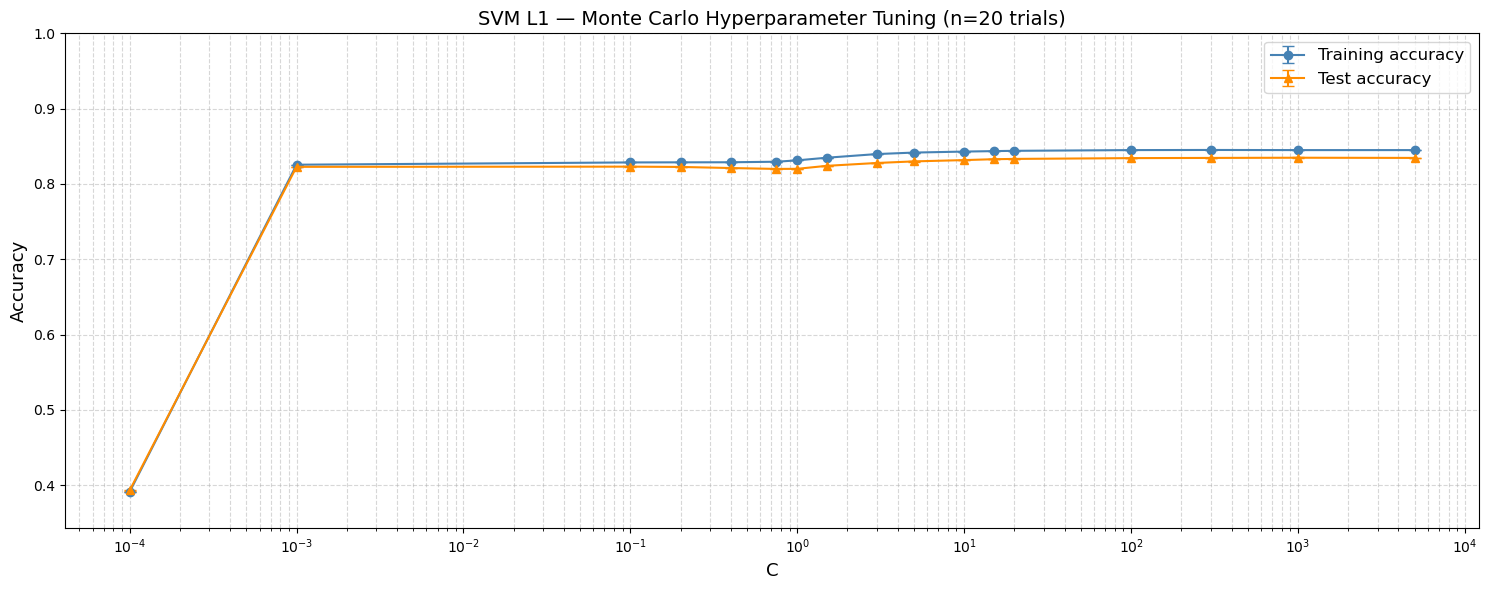

Highest Test Set Achieved = 0.834868
Best C Parameter          = 1000


In [12]:
# Monte Carlo Graph — SVM L1
fig = plt.figure(figsize=(15, 6))
plt.xscale('log')
plt.errorbar(C_l1, all_training_l1.mean(axis=1),
             yerr=all_training_l1.var(axis=1),
             label='Training accuracy', marker='o', color='steelblue', capsize=4)
plt.errorbar(C_l1, all_test_l1.mean(axis=1),
             yerr=all_test_l1.var(axis=1),
             label='Test accuracy', marker='^', color='darkorange', capsize=4)
plt.ylabel('Accuracy', fontsize=13)
plt.xlabel('C', fontsize=13)
plt.title(f'SVM L1 — Monte Carlo Hyperparameter Tuning (n={No_trials_l1} trials)', fontsize=14)
plt.ylim(max(0, all_test_l1.mean(axis=1).min() - 0.05), 1.0)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Highest Test Set Achieved = {np.amax(all_test_l1.mean(axis=1)):.6f}")
print(f"Best C Parameter          = {C_l1[np.argmax(all_test_l1.mean(axis=1))]}")


### A-4. SVM L1 — Best C and Best Predictor Feature

In [13]:
# Refit SVM L1 with best C from Monte Carlo
best_C_l1 = C_l1[np.argmax(all_test_l1.mean(axis=1))]

svm_l1_best = LinearSVC(C=best_C_l1, penalty="l1", loss='squared_hinge',
                         dual=False, max_iter=10000).fit(X_train_sc, y_train)

print(f"Best C from Monte Carlo : {best_C_l1}")
print(f"Training set score      : {svm_l1_best.score(X_train_sc, y_train):.6f}")
print(f"Test set score          : {svm_l1_best.score(X_test_sc,  y_test):.6f}")

# coef_ shape is (n_classes, n_features) for multi-class,
# or (1, n_features) for binary — take mean absolute value across classes
# then pick the feature with the highest average |coefficient|
coef_l1_matrix = svm_l1_best.coef_                          # shape: (n_classes, n_features)
coef_l1        = np.abs(coef_l1_matrix).mean(axis=0)       # shape: (n_features,)
top_idx_l1     = int(np.argmax(coef_l1))                   # always within feature_cols bounds

print(f"\nTop Predictor = {feature_cols[top_idx_l1]}")
print(f"Top Predictor Weight of ML with highest prediction = {coef_l1[top_idx_l1]:.6f}")


Best C from Monte Carlo : 1000
Training set score      : 0.835821
Test set score          : 0.852632

Top Predictor = review_age_days
Top Predictor Weight of ML with highest prediction = 10.457055


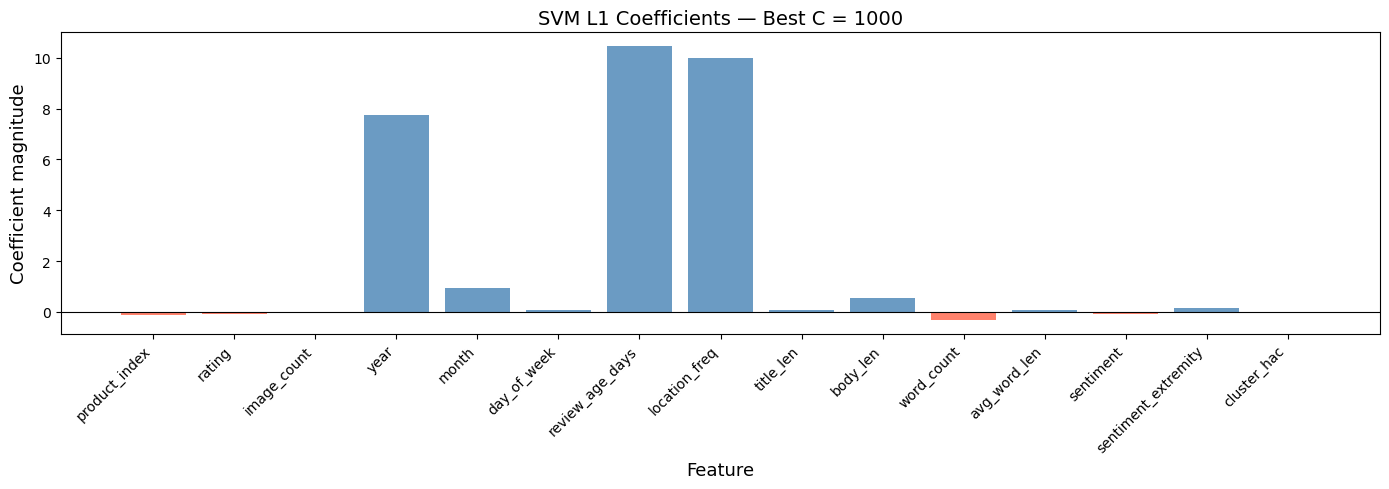

In [14]:
# Coefficient plot — SVM L1, best C
fig = plt.figure(figsize=(14, 5))
x_pos = np.arange(len(feature_cols))

# coef_l1 is already mean |coef| per feature (from A-4 cell above)
raw_coef_l1 = svm_l1_best.coef_.mean(axis=0)   # signed mean for direction colour
plt.bar(x_pos, raw_coef_l1,
        color=['tomato' if v < 0 else 'steelblue' for v in raw_coef_l1], alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x_pos, feature_cols, rotation=45, ha='right', fontsize=10)
plt.xlabel('Feature', fontsize=13)
plt.ylabel('Coefficient magnitude', fontsize=13)
plt.title(f'SVM L1 Coefficients — Best C = {best_C_l1}', fontsize=14)
plt.tight_layout()
plt.show()


---
# Part B — Support Vector Machine with L2 Regularization (SVM L2)

`LinearSVC(penalty="l2")` — the default penalty in scikit-learn.

Same four-step structure as Part A.


### B-1. SVM L2 — Single C (C = 1)

In [15]:
# SVM L2 with C = 1
C_single_l2 = 1

svm_l2_single = LinearSVC(
    C=C_single_l2,
    penalty="l2",
    max_iter=10000
).fit(X_train_sc, y_train)

print(f"SVM L2  |  C = {C_single_l2}")
print(f"  Training set score : {svm_l2_single.score(X_train_sc, y_train):.6f}")
print(f"  Test set score     : {svm_l2_single.score(X_test_sc,  y_test):.6f}")


SVM L2  |  C = 1
  Training set score : 0.821773
  Test set score     : 0.834211


In [16]:
# Classification Report — SVM L2, C = 1
y_pred_l2_single = svm_l2_single.predict(X_test_sc)
print("Classification Report (SVM L2, C=1):")
print(classification_report(y_test, y_pred_l2_single,
                             labels=unique_classes, target_names=target_names))


Classification Report (SVM L2, C=1):
              precision    recall  f1-score   support

           0       0.93      0.61      0.74       145
           1       0.80      0.97      0.88       235

    accuracy                           0.83       380
   macro avg       0.86      0.79      0.81       380
weighted avg       0.85      0.83      0.83       380



/var/folders/pm/m1_pb85j4pg9khxpn240nmth0000gn/T/ipykernel_11447/1646570813.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=30, ha='left')
/var/folders/pm/m1_pb85j4pg9khxpn240nmth0000gn/T/ipykernel_11447/1646570813.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(tick_labels)


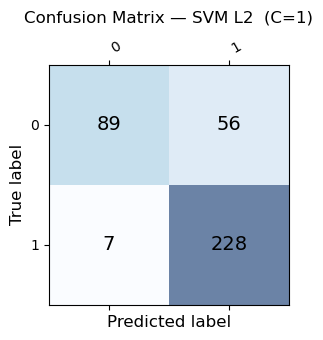

In [17]:
# Confusion Matrix — SVM L2, C = 1
confmat_l2_single = confusion_matrix(y_true=y_test, y_pred=y_pred_l2_single,
                                     labels=unique_classes)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.matshow(confmat_l2_single, cmap=plt.cm.Blues, alpha=0.6)
for i in range(confmat_l2_single.shape[0]):
    for j in range(confmat_l2_single.shape[1]):
        ax.text(x=j, y=i, s=confmat_l2_single[i, j], va='center', ha='center', fontsize=14)
tick_labels = [''] + target_names
ax.set_xticklabels(tick_labels, rotation=30, ha='left')
ax.set_yticklabels(tick_labels)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(f'Confusion Matrix — SVM L2  (C={C_single_l2})', fontsize=12, pad=12)
plt.tight_layout()
plt.show()


### B-2. SVM L2 — Range of C Values

In [18]:
# SVM L2: scores over a range of C values (single split)
C_range_l2 = [1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

train_scores_l2 = []
test_scores_l2  = []

for c in C_range_l2:
    svm = LinearSVC(C=c, penalty="l2", max_iter=10000)
    svm.fit(X_train_sc, y_train)
    train_scores_l2.append(svm.score(X_train_sc, y_train))
    test_scores_l2.append(svm.score(X_test_sc,  y_test))
    print(f"C = {c:>8}  |  train: {train_scores_l2[-1]:.4f}  |  test: {test_scores_l2[-1]:.4f}")


C =   0.0001  |  train: 0.8016  |  test: 0.8158
C =    0.001  |  train: 0.8200  |  test: 0.8289
C =      0.1  |  train: 0.8227  |  test: 0.8342
C =      0.2  |  train: 0.8218  |  test: 0.8342
C =      0.4  |  train: 0.8209  |  test: 0.8342
C =     0.75  |  train: 0.8218  |  test: 0.8368
C =        1  |  train: 0.8218  |  test: 0.8342
C =      1.5  |  train: 0.8218  |  test: 0.8342
C =        3  |  train: 0.8262  |  test: 0.8289
C =        5  |  train: 0.8244  |  test: 0.8263
C =       10  |  train: 0.8297  |  test: 0.8368
C =       15  |  train: 0.8323  |  test: 0.8368
C =       20  |  train: 0.8349  |  test: 0.8421
C =      100  |  train: 0.8323  |  test: 0.8526
C =      300  |  train: 0.8341  |  test: 0.8447
C =     1000  |  train: 0.8262  |  test: 0.8342
C =     5000  |  train: 0.7076  |  test: 0.7211


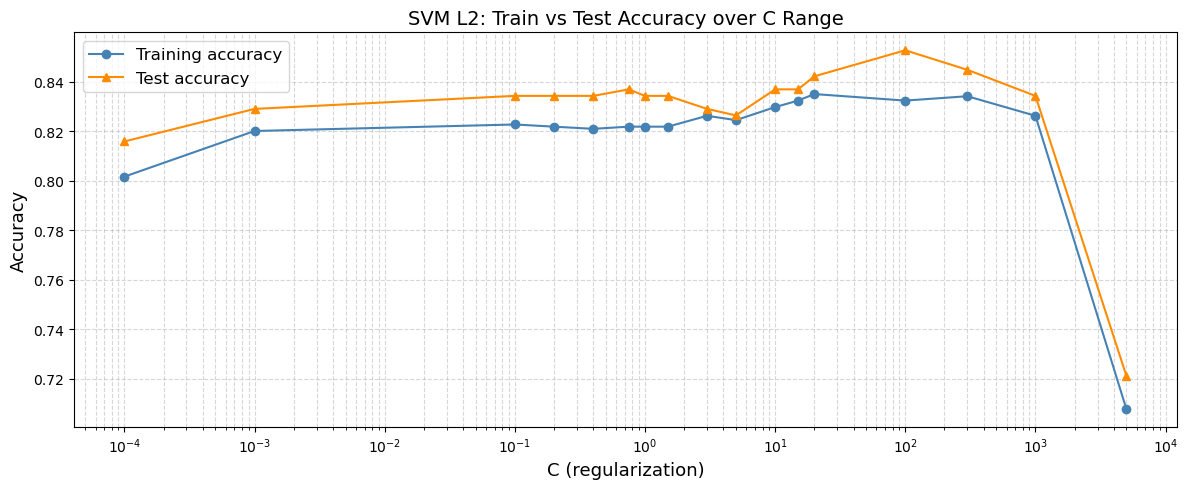

Best test accuracy (single split): 0.852632
Best C (single split)            : 100


In [19]:
# Plot — SVM L2 range of C
fig = plt.figure(figsize=(12, 5))
plt.xscale('log')
plt.plot(C_range_l2, train_scores_l2, '-o', label='Training accuracy', color='steelblue')
plt.plot(C_range_l2, test_scores_l2,  '-^', label='Test accuracy',     color='darkorange')
plt.xlabel('C (regularization)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('SVM L2: Train vs Test Accuracy over C Range', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_idx_l2_range = int(np.argmax(test_scores_l2))
print(f"Best test accuracy (single split): {test_scores_l2[best_idx_l2_range]:.6f}")
print(f"Best C (single split)            : {C_range_l2[best_idx_l2_range]}")


### B-3. SVM L2 — Monte Carlo Hyperparameter Tuning for C

Same 20-trial Monte Carlo structure as Part A, using L2 penalty.


In [20]:
# Monte Carlo: 20 trials, SVM L2
No_trials_l2 = 20
C_l2 = [1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

all_training_l2 = pd.DataFrame()
all_test_l2     = pd.DataFrame()

for seedN in range(1, No_trials_l2 + 1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=0.25, random_state=seedN)
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc  = sc.transform(X_te)

    train_acc = []
    test_acc  = []
    for alpha_run in C_l2:
        svm_l2 = LinearSVC(C=alpha_run, penalty="l2", max_iter=10000).fit(X_tr_sc, y_tr)
        train_acc.append(svm_l2.score(X_tr_sc, y_tr))
        test_acc.append(svm_l2.score(X_te_sc,  y_te))
    all_training_l2[seedN] = train_acc
    all_test_l2[seedN]     = test_acc

print(f"Monte Carlo complete: {No_trials_l2} trials x {len(C_l2)} C values")


Monte Carlo complete: 20 trials x 17 C values


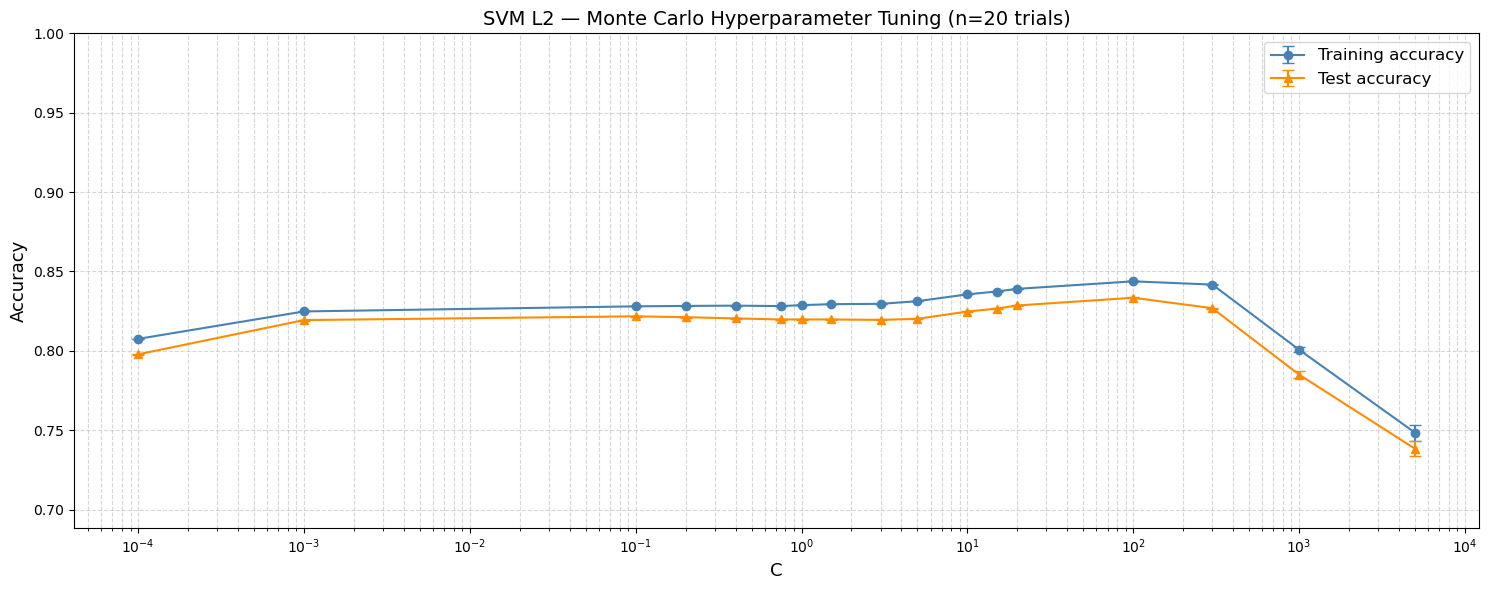

Highest Test Set Achieved = 0.833421
Best C Parameter          = 100


In [21]:
# Monte Carlo Graph — SVM L2
fig = plt.figure(figsize=(15, 6))
plt.xscale('log')
plt.errorbar(C_l2, all_training_l2.mean(axis=1),
             yerr=all_training_l2.var(axis=1),
             label='Training accuracy', marker='o', color='steelblue', capsize=4)
plt.errorbar(C_l2, all_test_l2.mean(axis=1),
             yerr=all_test_l2.var(axis=1),
             label='Test accuracy', marker='^', color='darkorange', capsize=4)
plt.ylabel('Accuracy', fontsize=13)
plt.xlabel('C', fontsize=13)
plt.title(f'SVM L2 — Monte Carlo Hyperparameter Tuning (n={No_trials_l2} trials)', fontsize=14)
plt.ylim(max(0, all_test_l2.mean(axis=1).min() - 0.05), 1.0)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Highest Test Set Achieved = {np.amax(all_test_l2.mean(axis=1)):.6f}")
print(f"Best C Parameter          = {C_l2[np.argmax(all_test_l2.mean(axis=1))]}")


### B-4. SVM L2 — Best C and Best Predictor Feature

In [22]:
# Refit SVM L2 with best C from Monte Carlo
best_C_l2 = C_l2[np.argmax(all_test_l2.mean(axis=1))]

svm_l2_best = LinearSVC(C=best_C_l2, penalty="l2",
                         max_iter=10000).fit(X_train_sc, y_train)

print(f"Best C from Monte Carlo : {best_C_l2}")
print(f"Training set score      : {svm_l2_best.score(X_train_sc, y_train):.6f}")
print(f"Test set score          : {svm_l2_best.score(X_test_sc,  y_test):.6f}")

# Same fix: average |coef| across classes, index stays within feature_cols
coef_l2_matrix = svm_l2_best.coef_
coef_l2        = np.abs(coef_l2_matrix).mean(axis=0)
top_idx_l2     = int(np.argmax(coef_l2))

print(f"\nTop Predictor = {feature_cols[top_idx_l2]}")
print(f"Top Predictor Weight of ML with highest prediction = {coef_l2[top_idx_l2]:.6f}")


Best C from Monte Carlo : 100
Training set score      : 0.838455
Test set score          : 0.850000

Top Predictor = review_age_days
Top Predictor Weight of ML with highest prediction = 10.045340


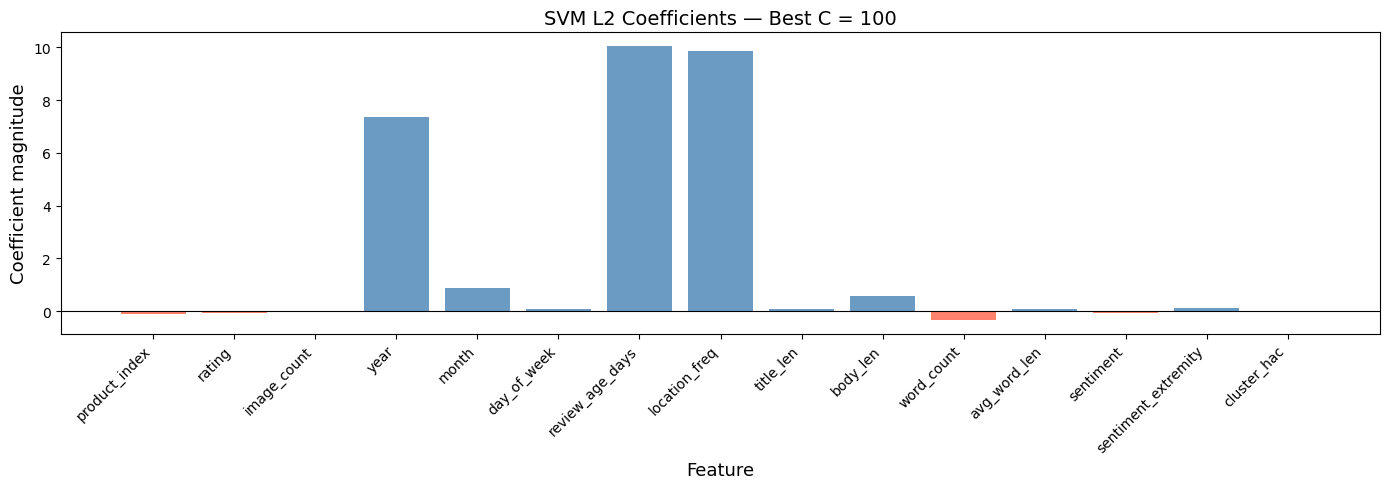

In [23]:
# Coefficient plot — SVM L2, best C
fig = plt.figure(figsize=(14, 5))
x_pos = np.arange(len(feature_cols))

raw_coef_l2 = svm_l2_best.coef_.mean(axis=0)
plt.bar(x_pos, raw_coef_l2,
        color=['tomato' if v < 0 else 'steelblue' for v in raw_coef_l2], alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x_pos, feature_cols, rotation=45, ha='right', fontsize=10)
plt.xlabel('Feature', fontsize=13)
plt.ylabel('Coefficient magnitude', fontsize=13)
plt.title(f'SVM L2 Coefficients — Best C = {best_C_l2}', fontsize=14)
plt.tight_layout()
plt.show()


---
## Summary of Results

In [24]:
summary = pd.DataFrame({
    'ML Method'    : ['Linear SVM (L1)', 'Linear SVM (L2)'],
    'Test Accuracy': [
        f"{np.amax(all_test_l1.mean(axis=1))*100:.2f}%",
        f"{np.amax(all_test_l2.mean(axis=1))*100:.2f}%"
    ],
    'Best C': [best_C_l1, best_C_l2],
    'Top Predictor': [feature_cols[top_idx_l1], feature_cols[top_idx_l2]]
})

print(summary.to_string(index=False))


      ML Method Test Accuracy  Best C   Top Predictor
Linear SVM (L1)        83.49%    1000 review_age_days
Linear SVM (L2)        83.34%     100 review_age_days
